# **Librerias y Funciones**

In [60]:
!pip install ripser

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import bisect
import math
import random

from ripser import ripser
from persim import plot_diagrams
from persim import PersistenceImager

from mpl_toolkits.mplot3d import Axes3D
from  mpl_toolkits  import  mplot3d

from scipy.cluster.hierarchy import dendrogram, linkage, set_link_color_palette
from scipy.integrate import odeint

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
from sklearn.datasets import make_blobs

In [62]:
#Funcion para calcular Landscapes
def persistence_landscape(diag):
    diag.sort(key=lambda x: (x[0], -x[1]))

    L = []
    k = 0

    while len(diag) > 0:
        Lk = []
        b, d = diag.pop(0)

        Lk.extend([(float('-inf'), 0), (b, 0), ((b + d) / 2, (d - b) / 2)])


        while Lk[-1] != (float('inf'), 0):

            if not diag or d >= max((item[1] for item in diag), default=-float('inf')):
                Lk.extend([(d, 0), (float('inf'), 0)])
            else:

                idx_prime = -1
                for i, (bp, dp) in enumerate(diag):
                    if dp > d:
                        idx_prime = i
                        break

                b_prime, d_prime = diag.pop(idx_prime)

                if b_prime > d:
                    Lk.append((d, 0))

                if b_prime >= d:
                    Lk.append((b_prime, 0))
                else:
                    Lk.append(((b_prime + d) / 2, (d - b_prime) / 2))

                    new_item = (b_prime, d)

                    bisect.insort(diag, new_item, key=lambda x: (x[0], -x[1]))

                Lk.append(((b_prime + d_prime) / 2, (d_prime - b_prime) / 2))
                b, d = b_prime, d_prime

        L.append(Lk)
        k += 1

    return L

#Funcion para graficar el diagrama de persistencia
def graficar_diag(dgms, Titulo, guardado):
    fig, ax = plt.subplots(figsize=(7, 7))

    max_val = max([np.nanmax(d[np.isfinite(d)]) for d in dgms if d.size > 0]) * 1.1
    ax.plot([0, max_val], [0, max_val], '--', color='black', alpha=1)

    x_vals = np.linspace(0, max_val, 100)
    ax.fill_between(x_vals, 0, x_vals, color='lightgray', alpha=0.8)

    colors = ['#2AA58B', '#804C80', '#27ae60', '#c0392b']
    labels = ['$H_0$', '$H_1$', '$H_2$', '$H_3$']

    for i, dgm in enumerate(dgms):
        if dgm.size > 0:
            clean_dgm = dgm[np.isfinite(dgm).all(axis=1)]

            ax.scatter(clean_dgm[:, 0], clean_dgm[:, 1],
                      color=colors[i],
                      label=labels[i],
                      s=80,
                      alpha=0.8,
                      edgecolors='none')

    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_xlim(-0.03*max_val, max_val)
    ax.set_ylim(0, max_val)
    ax.set_xlabel('Nacimiento', fontsize=15)
    ax.set_ylabel('Muerte', fontsize=15)
    ax.set_title(f'{Titulo}', fontsize=15)
    ax.legend()
    plt.savefig(f'{guardado}', bbox_inches='tight')
    plt.show()

# **Importe de los Datos y Calculo de sus Diagramas de Persistencia**

In [63]:
#Número de órbitas para cada atractor
elem_tipo=10

rho = 15.0
sigma = 10.0
beta = 8.0 / 3.0
t = np.arange(0.0, 40.0, 0.1)
Lorentz=[]

def lorentz(state, t):
    x, y, z = state
    return sigma * (y - x), x * (rho - z) - y, x * y - beta * z

# Generar órbitas
for j in range(elem_tipo):
  # Condiciones iniciales
  state0 = [random.uniform(-5, 5), random.uniform(-5, 5), random.uniform(-5, 5)]

  # Resolver el sistema
  states = odeint(lorentz, state0, t)

  Lorentz.append(states)

In [64]:
# Parámetros del sistema Lotka-Volterra
alpha = 1.0   # Tasa de crecimiento de presas
beta = 0.1    # Tasa de depredación de presas
delta = 0.1   # Tasa de crecimiento de depredadores
gamma = 1.0   # Tasa de muerte de depredadores

def lotka_volterra(state, t):
    x, y = state
    dx_dt = alpha * x - beta * x * y
    dy_dt = delta * x * y - gamma * y
    return [dx_dt, dy_dt]

t = np.arange(0.0, 40.0, 0.1)
Lotka_Volterra=[]

# Generar órbitas
for j in range(elem_tipo):
    # Condiciones iniciales
    state0 = [random.uniform(5, 30), random.uniform(1, 10)]

    # Resolver el sistema
    states = odeint(lotka_volterra, state0, t)

    aux=[]
    for i in range(len(states)):
        aux.append(np.append(states[i],0).tolist())
    Lotka_Volterra.append(aux)

Lotka_Volterra = np.array(Lotka_Volterra)

In [65]:
#Importe de los datos
Datos=np.concatenate((Lorentz,Lotka_Volterra))

#Nombres para cada dato
nombres=[]
for i in range(elem_tipo):
  nombres.append(f'$L_{{{i+1}}}$')

for i in range(elem_tipo):
  nombres.append(f'$V_{{{i+1}}}$')

#Categorias de los datos
tipo_dato=['Lorentz','Lotka_Volterra']

#Número de elementos por categoria
elem_tipo=10




#Título para las gráficas
titulo='Lorentz vs Lotka-Volterra'

#Colores para las gráficas
colores = ['#603160', '#D49AD4', '#2AA58B', '#AEEEE2']

#Etiquetas para las gráficas
etiquetas=[]
for i in range(len(tipo_dato)):
    etiquetas=etiquetas+list([tipo_dato[i]]*elem_tipo)

In [66]:
#Calcular Diagramas de Persistencia
diagramas_persistencia=[]
for j in range(0,len(Datos)):
    diagramas_persistencia.append(ripser(Datos[j], maxdim=1)['dgms'])

# **Visualización de Datos y Diagramas**

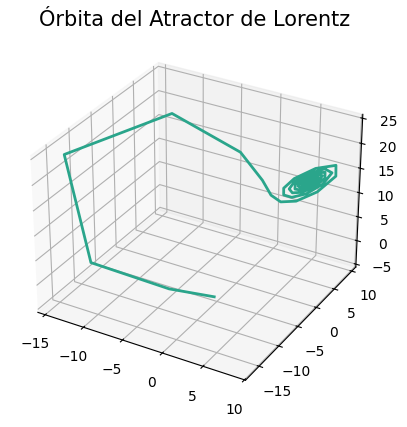

In [67]:
fig = plt.figure( )
ax = plt.axes(projection='3d')
ax.plot3D(Datos[0][:,0],  Datos[0][:,1],  Datos[0][:,2], color='#2AA58B')
plt.title("Órbita del Atractor de Lorentz", fontsize=15)
plt.show()

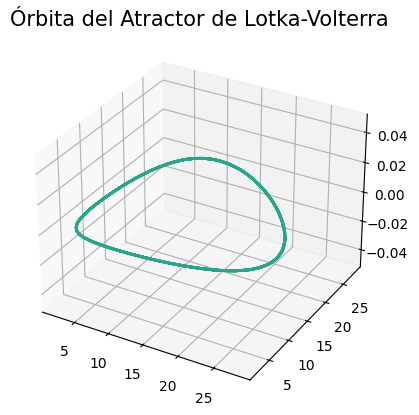

In [68]:
fig = plt.figure( )
ax = plt.axes(projection='3d')
ax.plot3D(Datos[10][:,0],  Datos[10][:,1],  Datos[10][:,2], color='#2AA58B')
plt.title("Órbita del Atractor de Lotka-Volterra", fontsize=15)
plt.show()

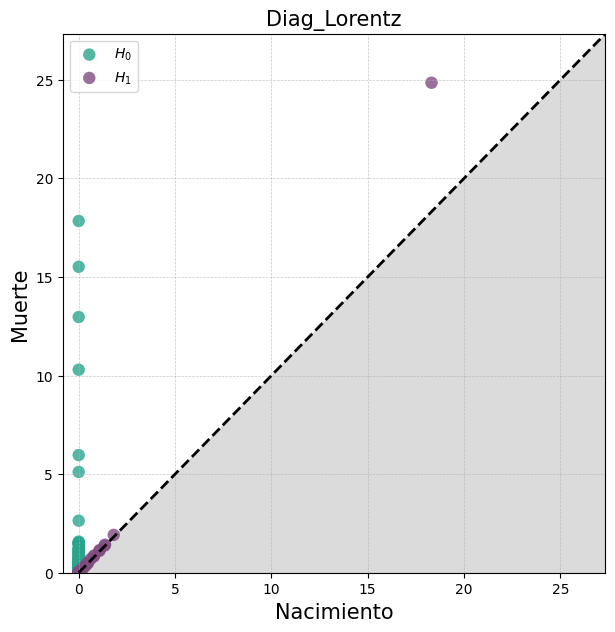

In [69]:
graficar_diag(diagramas_persistencia[0], Titulo='Diag_Lorentz', guardado='Diag_Lorentz')

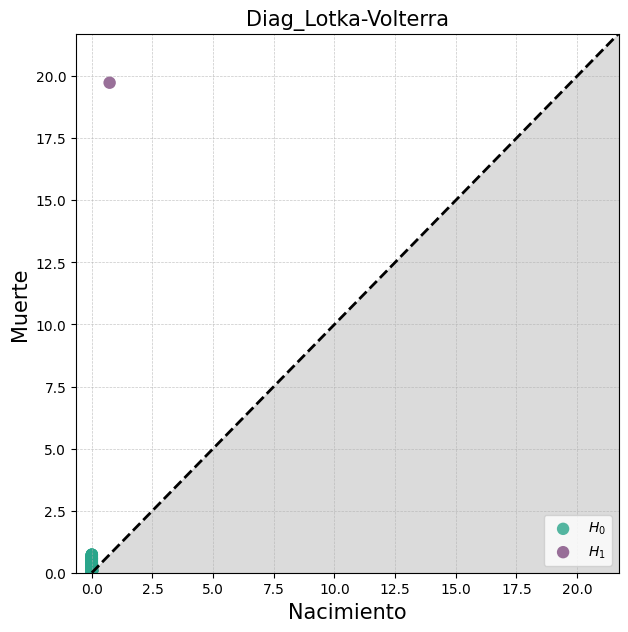

In [70]:
graficar_diag(diagramas_persistencia[10], Titulo='Diag_Lotka-Volterra', guardado='Diag_Lotka-Volterra')

# **Concatenacion**

In [71]:
#Calcular vectorización mediante concatenación
concatenacion_planos=[]
for j in range(len(Datos)):
  if diagramas_persistencia[j][1].tolist()!=[]:
    concatenacion_planos.append(diagramas_persistencia[j][1].flatten())
  else:
    concatenacion_planos.append([])


In [72]:
#Aplicar Padding
dimensiones_concatenacion=[]
for j in range(len(Datos)):
  dimensiones_concatenacion.append(len(concatenacion_planos[j]))

concatenacion_planos_padding=[]

for j in range(len(Datos)):
  ceros=np.zeros(max(dimensiones_concatenacion)-len(concatenacion_planos[j]))
  concatenacion_planos_padding.append(np.concatenate((concatenacion_planos[j], ceros)))

In [73]:
#Coeficiente de silueta natural
score = silhouette_score(concatenacion_planos_padding, etiquetas)
print(f"Coeficiente de silueta natural: {score}")

Coeficiente de silueta natural: 0.48909486604594604


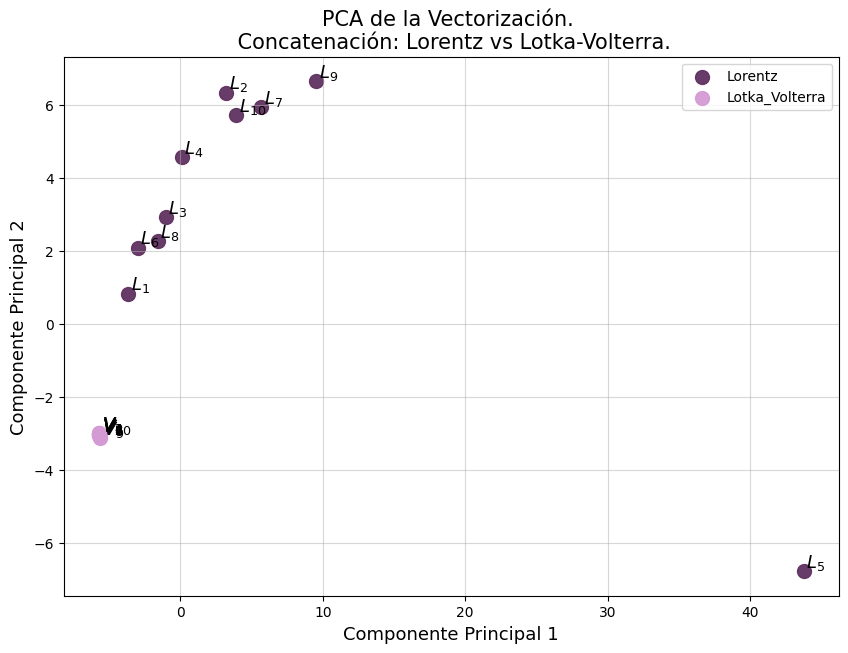

In [74]:
#Aplicar PCA de dimensión dos para visualizar los datos
pca=PCA(n_components=2)

X_scaled = StandardScaler().fit_transform(concatenacion_planos_padding)

concatenacion_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

for i in range(len(tipo_dato)):
    inicio, fin = i*elem_tipo, (i+1)*elem_tipo
    plt.scatter(concatenacion_pca[:,0][inicio:fin], concatenacion_pca[:,1][inicio:fin], c=colores[i], label=tipo_dato[i], s=100, alpha=0.95)

for i in range(len(concatenacion_pca[:,0])):
    plt.annotate(nombres[i], (concatenacion_pca[:,0][i], concatenacion_pca[:,1][i]), xytext=(2, 3), textcoords="offset points", ha='left',fontsize=13)

plt.title(f"PCA de la Vectorización. \n Concatenación: {titulo}.", fontsize=15)
plt.grid(True, alpha=0.5)
plt.legend()
plt.xlabel(r"Componente Principal 1", fontsize=13)
plt.ylabel(r"Componente Principal 2", fontsize=13)
plt.savefig(f"PCA_Concatenacion_{titulo}.png", dpi=300, bbox_inches='tight')

plt.show()

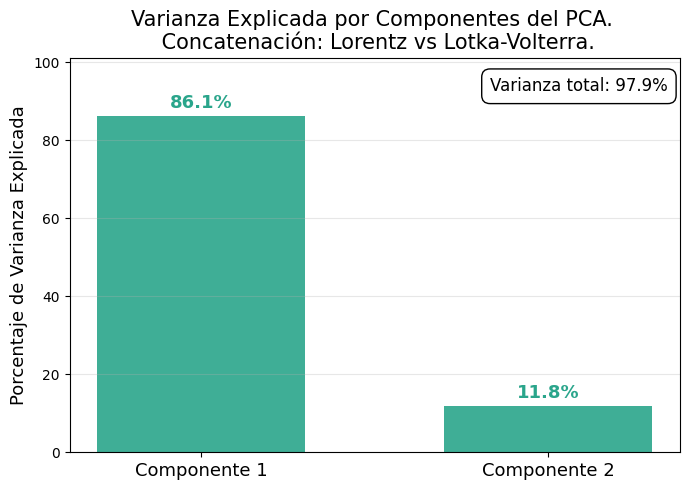

In [75]:
# Varianza explicada del PCA
varianza_explicada = pca.explained_variance_ratio_
varianza_total = sum(varianza_explicada) * 100

plt.figure(figsize=(7, 5))

x = [1, 2]
y = varianza_explicada * 100
bars = plt.bar(x, y, alpha=0.9, color='#2AA58B', width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=13, color="#2AA58B", fontweight='bold')

# 4. Personalizar el eje X
plt.xticks([1, 2], ['Componente 1', 'Componente 2'], fontsize=13)
plt.ylabel('Porcentaje de Varianza Explicada', fontsize=13)
plt.title(f'Varianza Explicada por Componentes del PCA. \n Concatenación: {titulo}.', fontsize=15)
plt.grid(axis='y', alpha=0.3)

plt.text(0.98, 0.95, f'Varianza total: {varianza_total:.1f}%',
         transform=plt.gca().transAxes,
         ha='right', va='top',
         fontsize=12,
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.5'))


plt.ylim(0, max(y) + 15)
plt.tight_layout()
plt.savefig(f"Varianza Concatenación {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

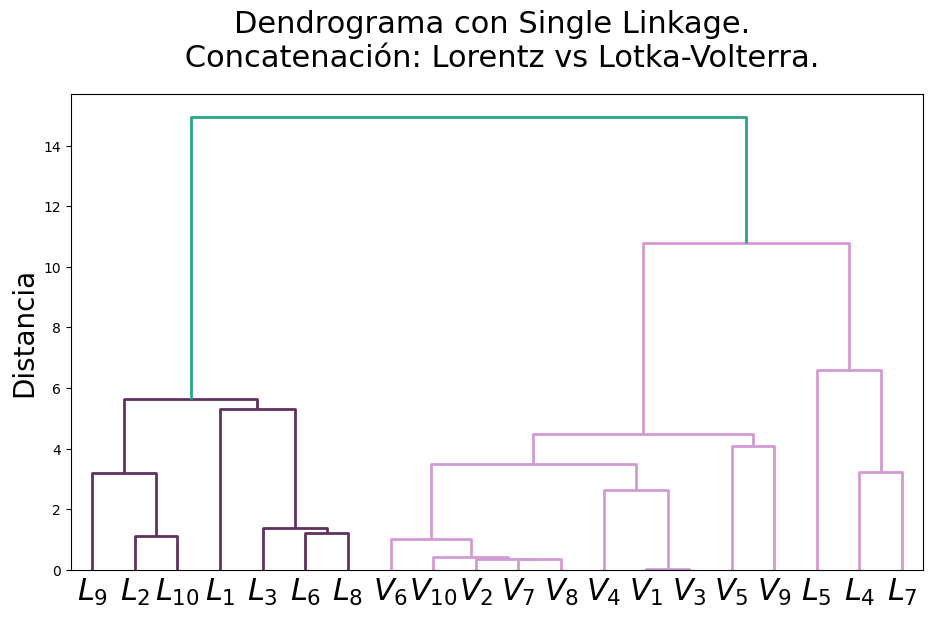

In [76]:
#Calcular el dendrograma single linkage de la vectorización
Z_S = linkage(concatenacion_planos_padding, method='single', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

plt.figure(figsize=(11, 7))

umbral_manual = 14
color_final = colores[2]

dendro = dendrogram(Z_S, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.2

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=22)


plt.title(f'Dendrograma con Single Linkage. \n Concatenación: {titulo}.', fontsize=22, pad=20)
plt.ylabel('Distancia', fontsize=20)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Single Linkage Concatenación {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

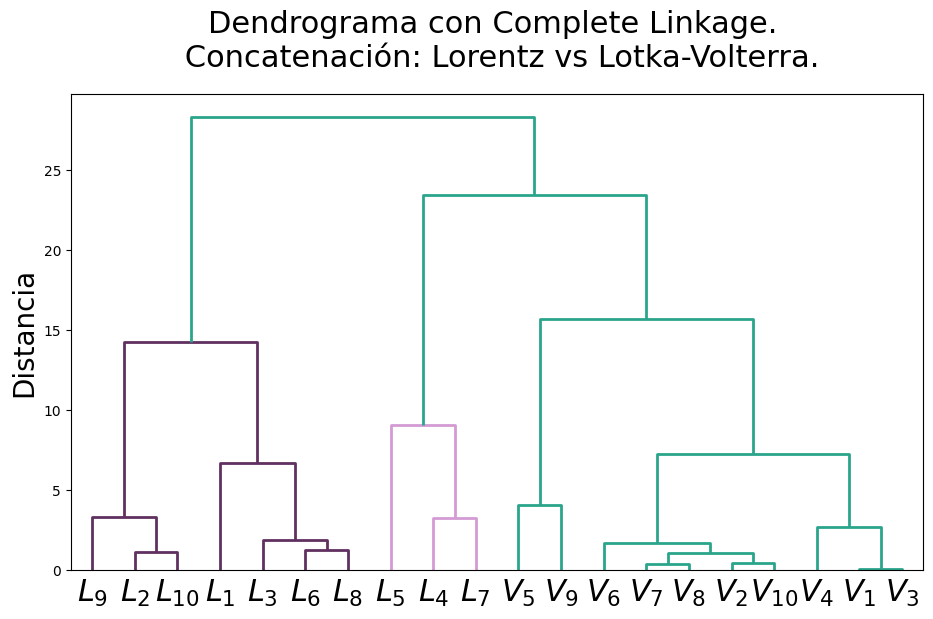

In [77]:
#Calcular el dendrograma complete linkage de la vectorización
Z_C = linkage(concatenacion_planos_padding, method='complete', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 20
color_final = colores[2]

dendro = dendrogram(Z_C, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.5

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=22)


plt.title(f'Dendrograma con Complete Linkage. \n Concatenación: {titulo}.', fontsize=22, pad=20)
plt.ylabel('Distancia', fontsize=20)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Complete Linkage Concatenación {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

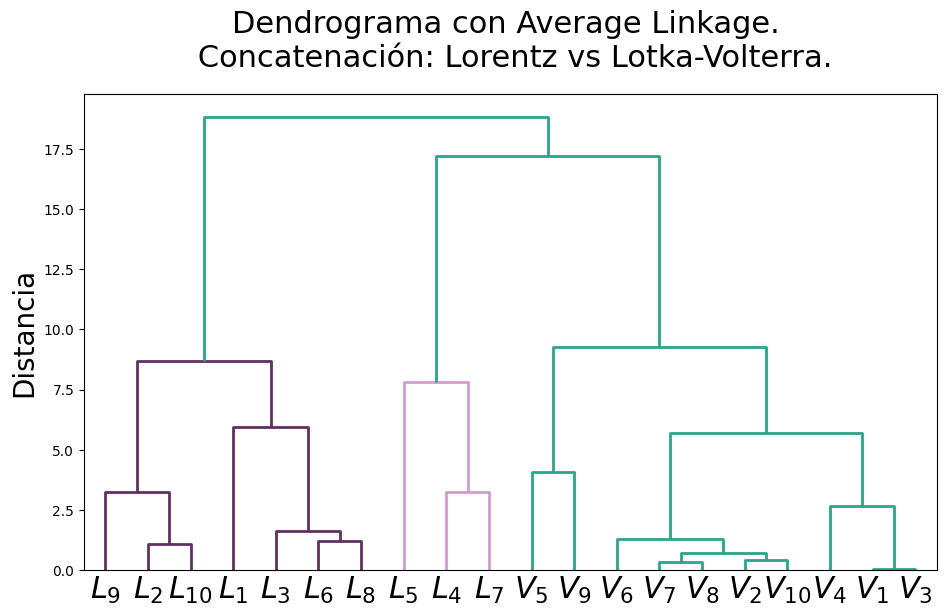

In [78]:
#Calcular el dendrograma average linkage de la vectorización
Z_A = linkage(concatenacion_planos_padding, method='average', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

plt.figure(figsize=(11, 7))

umbral_manual = 12
color_final = colores[2]

dendro = dendrogram(Z_A, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.2

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=22)


plt.title(f'Dendrograma con Average Linkage. \n Concatenación: {titulo}.', fontsize=22, pad=20)
plt.ylabel('Distancia', fontsize=20)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Average Linkage Concatenación {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

# **Landscapes**

In [79]:
#Calcular vectorización mediante landscapes
landscapes=[]

for j in range(len(Datos)):
    aux=diagramas_persistencia[j][1].tolist()

    if aux!=[]:
      landscapes.append(persistence_landscape(aux))
    else:
      landscapes.append([])

In [80]:
#Aplanar landscapes
landscapes_planos=[]
for j in range(len(Datos)):

  if landscapes[j]!=[]:
    aux=landscapes[j][0]
    for i in range(1,len(landscapes[j])):
      aux=np.concatenate((aux, landscapes[j][i]))

    aux=[p for p in aux if not math.isinf(p[0])]
    landscapes_planos.append(aux)
  else:
    landscapes_planos.append((0,0))

  landscapes_planos[j]=np.array(landscapes_planos[j]).flatten()

In [81]:
#Aplicar Padding
dimensiones=[]
for j in range(len(Datos)):
  dimensiones.append(len(landscapes_planos[j]))

landscapes_planos_padding=[]

for j in range(len(Datos)):
  ceros=np.zeros(max(dimensiones)-len(landscapes_planos[j]))
  landscapes_planos_padding.append(np.concatenate((landscapes_planos[j], ceros)))

In [82]:
#Coeficiente de silueta natural
score = silhouette_score(landscapes_planos_padding, etiquetas)
print(f"Coeficiente de silueta natural: {score}")

Coeficiente de silueta natural: 0.385997526433156


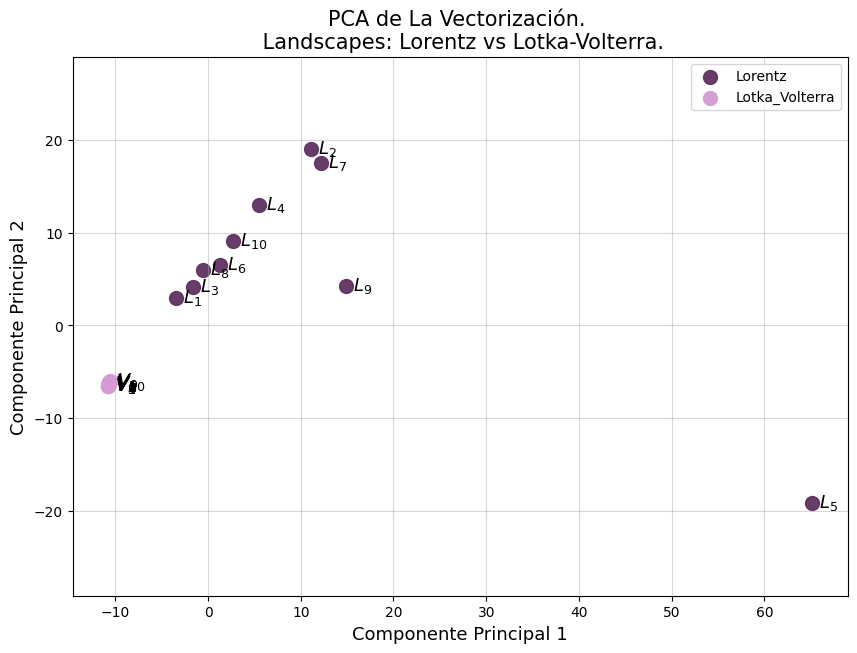

In [83]:
#Aplicar PCA de dimensión dos para visualizar los datos
pca=PCA(n_components=2)

X_scaled = StandardScaler().fit_transform(landscapes_planos_padding)

landscapes_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

for i in range(len(tipo_dato)):
    inicio, fin = i*elem_tipo, (i+1)*elem_tipo
    plt.scatter(landscapes_pca[:,0][inicio:fin], landscapes_pca[:,1][inicio:fin], c=colores[i], label=tipo_dato[i], s=100, alpha=0.95)

for i in range(len(landscapes_pca[:,0])):
    plt.annotate(nombres[i], (landscapes_pca[:,0][i], landscapes_pca[:,1][i]), xytext=(5, -3), textcoords="offset points", ha='left',fontsize=13)

plt.title(f"PCA de La Vectorización. \n Landscapes: {titulo}.", fontsize=15)
plt.grid(True, alpha=0.5)
plt.legend()
plt.xlabel(r"Componente Principal 1", fontsize=13)
plt.ylabel(r"Componente Principal 2", fontsize=13)
plt.savefig(f"PCA_Landscapes_{titulo}.png", dpi=300, bbox_inches='tight')
plt.axis('equal')
plt.show()

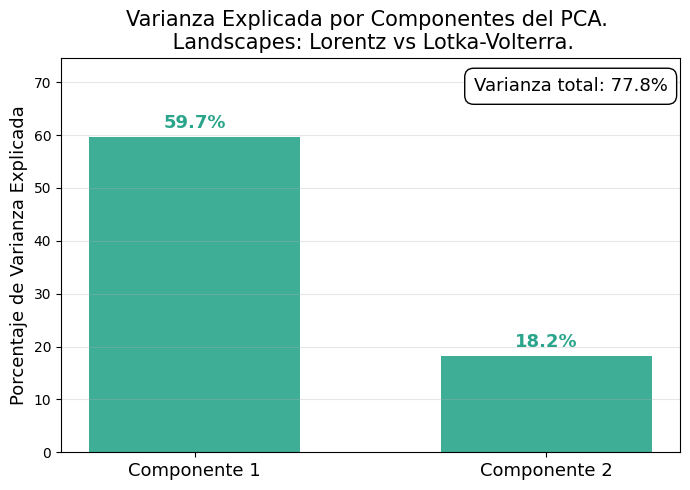

In [84]:
# Varianza explicada del PCA
varianza_explicada = pca.explained_variance_ratio_
varianza_total = sum(varianza_explicada) * 100

plt.figure(figsize=(7, 5))

x = [1, 2]
y = varianza_explicada * 100
bars = plt.bar(x, y, alpha=0.9, color='#2AA58B', width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=13, color="#2AA58B", fontweight='bold')

plt.xticks([1, 2], ['Componente 1', 'Componente 2'], fontsize=13)
plt.ylabel('Porcentaje de Varianza Explicada', fontsize=13)
plt.title(f'Varianza Explicada por Componentes del PCA. \n Landscapes: {titulo}.', fontsize=15)
plt.grid(axis='y', alpha=0.3)

plt.text(0.98, 0.95, f'Varianza total: {varianza_total:.1f}%',
         transform=plt.gca().transAxes,
         ha='right', va='top',
         fontsize=13,
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.5'))


plt.ylim(0, max(y) + 15)
plt.tight_layout()
plt.savefig(f"Varianza Landscapes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

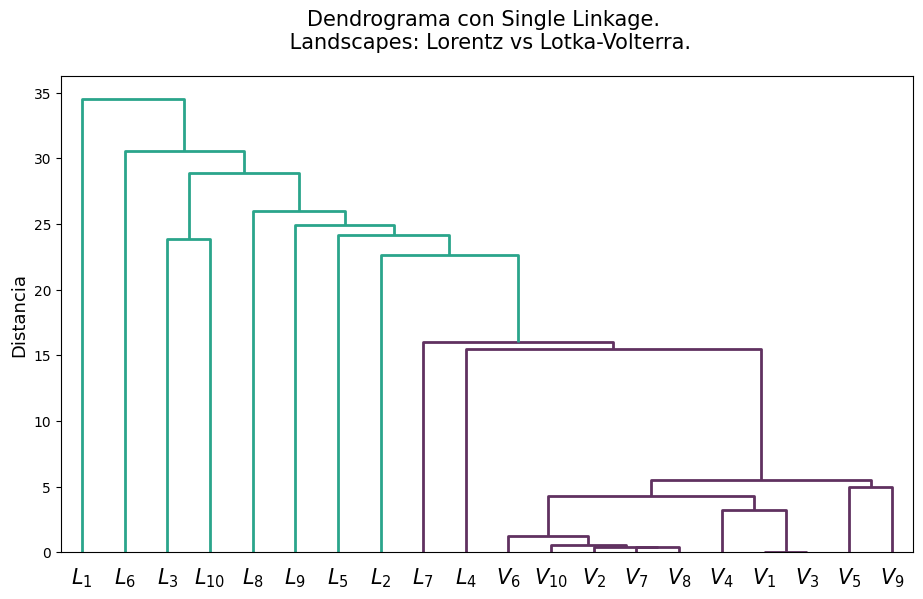

In [85]:
#Calcular el dendrograma single linkage de la vectorización
Z_S = linkage(landscapes_planos_padding, method='single', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 20
color_final = colores[2]

dendro = dendrogram(Z_S, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -1

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Single Linkage. \n Landscapes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Single Linkage Landscapes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

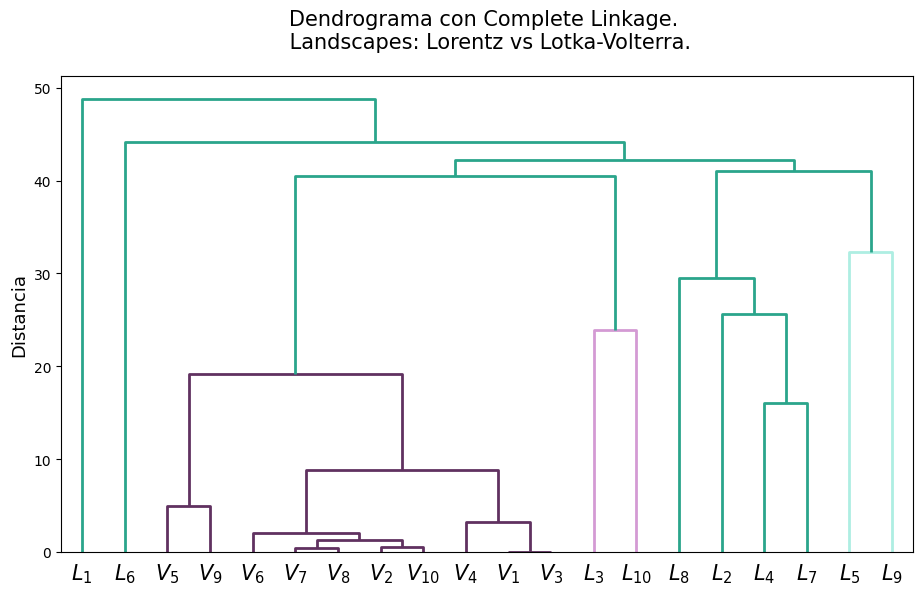

In [86]:
#Calcular el dendrograma complete linkage de la vectorización
Z_C = linkage(landscapes_planos_padding, method='complete', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 40
color_final = colores[2]

dendro = dendrogram(Z_C, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -1

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Complete Linkage. \n Landscapes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Complete Linkage Landscapes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

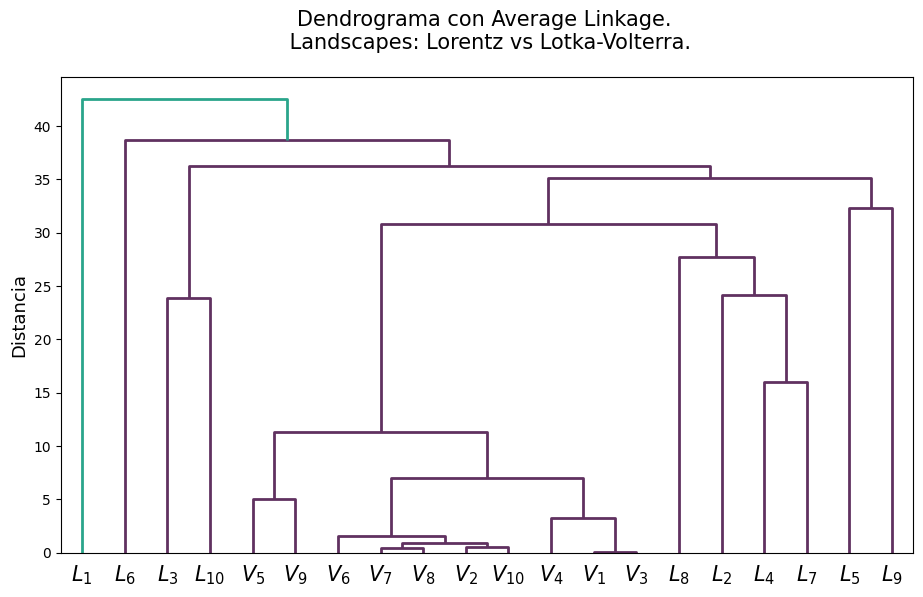

In [87]:
#Calcular el dendrograma average linkage de la vectorización
Z_A = linkage(landscapes_planos_padding, method='average', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 40
color_final = colores[2]

dendro = dendrogram(Z_A, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -1

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Average Linkage. \n Landscapes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Average Linkage Landscapes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

# **Imagenes Persistentes**

In [88]:
#Calcular vectorización mediante imágenes persistentes
imagenes_persistencia=[]
for j in range(0,len(Datos)):
    pimgr = PersistenceImager()
    pimgr.birth_range = (0, 12)
    pimgr.pers_range = (0, 10)
    pimgr.kernel_params = {'sigma': 5.0}
    imagenes_persistencia.append(pimgr.transform(diagramas_persistencia[j][1]))


In [89]:
#Aplanar imágenes persistentes
imagenes_planas=[]
for j in range(0,len(Datos)):
  imagenes_planas.append(imagenes_persistencia[j].flatten())

imagenes_planas=np.array(imagenes_planas)

In [90]:
#Coeficiente de silueta natural
score = silhouette_score(imagenes_planas, etiquetas)
print(f"Coeficiente de silueta natural: {score}")

Coeficiente de silueta natural: 0.22915395714934803


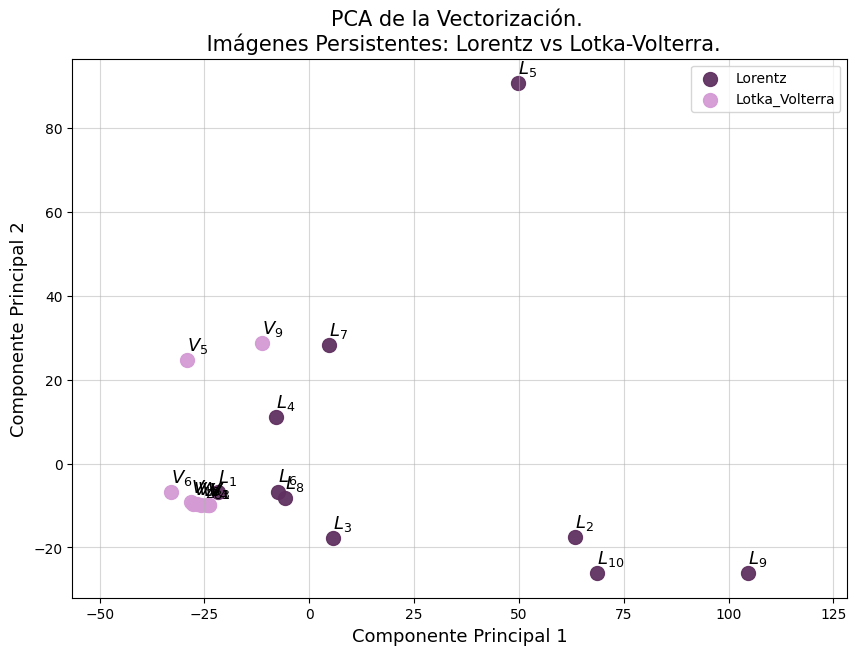

In [91]:
#Aplicar PCA de dimensión dos para visualizar los datos
pca=PCA(n_components=2)

X_scaled = StandardScaler().fit_transform(imagenes_planas)

imagenes_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

for i in range(len(tipo_dato)):
    inicio, fin = i*elem_tipo, (i+1)*elem_tipo
    plt.scatter(imagenes_pca[:,0][inicio:fin], imagenes_pca[:,1][inicio:fin], c=colores[i], label=tipo_dato[i], s=100, alpha=0.95)

for i in range(len(imagenes_pca[:,0])):
    plt.annotate(nombres[i], (imagenes_pca[:,0][i], imagenes_pca[:,1][i]), xytext=(0, 7), textcoords="offset points", ha='left',fontsize=13)


plt.title(f"PCA de la Vectorización. \n Imágenes Persistentes: {titulo}.", fontsize=15)
plt.grid(True, alpha=0.5)
plt.legend()
plt.xlabel(r"Componente Principal 1", fontsize=13)
plt.ylabel(r"Componente Principal 2", fontsize=13)
plt.savefig(f"PCA_Imagenes_Persistentes_{titulo}.png", dpi=300, bbox_inches='tight')
plt.axis('equal')
plt.show()

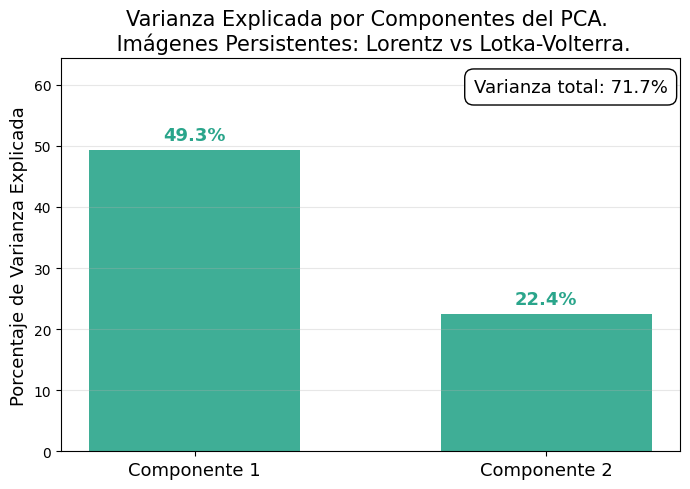

In [92]:
# Varianza explicada del PCA
varianza_explicada = pca.explained_variance_ratio_
varianza_total = sum(varianza_explicada) * 100

plt.figure(figsize=(7, 5))

x = [1, 2]
y = varianza_explicada * 100
bars = plt.bar(x, y, alpha=0.9, color='#2AA58B', width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=13, color="#2AA58B", fontweight='bold')

plt.xticks([1, 2], ['Componente 1', 'Componente 2'], fontsize=13)
plt.ylabel('Porcentaje de Varianza Explicada', fontsize=13)
plt.title(f'Varianza Explicada por Componentes del PCA. \n Imágenes Persistentes: {titulo}.', fontsize=15)
plt.grid(axis='y', alpha=0.3)

plt.text(0.98, 0.95, f'Varianza total: {varianza_total:.1f}%',
         transform=plt.gca().transAxes,
         ha='right', va='top',
         fontsize=13,
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.5'))


plt.ylim(0, max(y) + 15)
plt.tight_layout()
plt.savefig(f"Varianza Imagenes Persistentes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

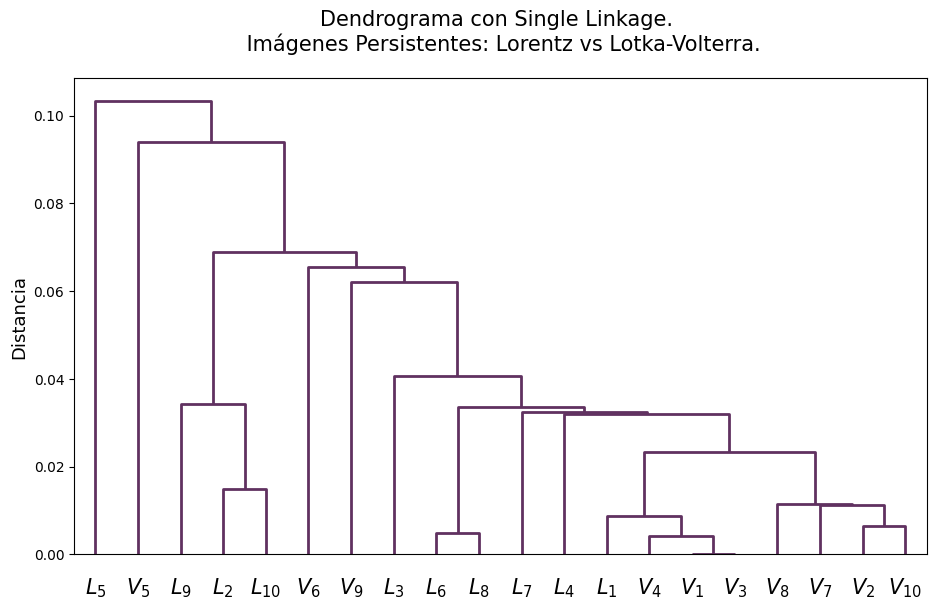

In [93]:
#Calcular el dendrograma single linkage de la vectorización
Z_S = linkage(imagenes_planas, method='single', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 0.25
color_final = colores[2]

dendro = dendrogram(Z_S, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.005

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Single Linkage. \n Imágenes Persistentes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Single Linkage Imagenes Persistentes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

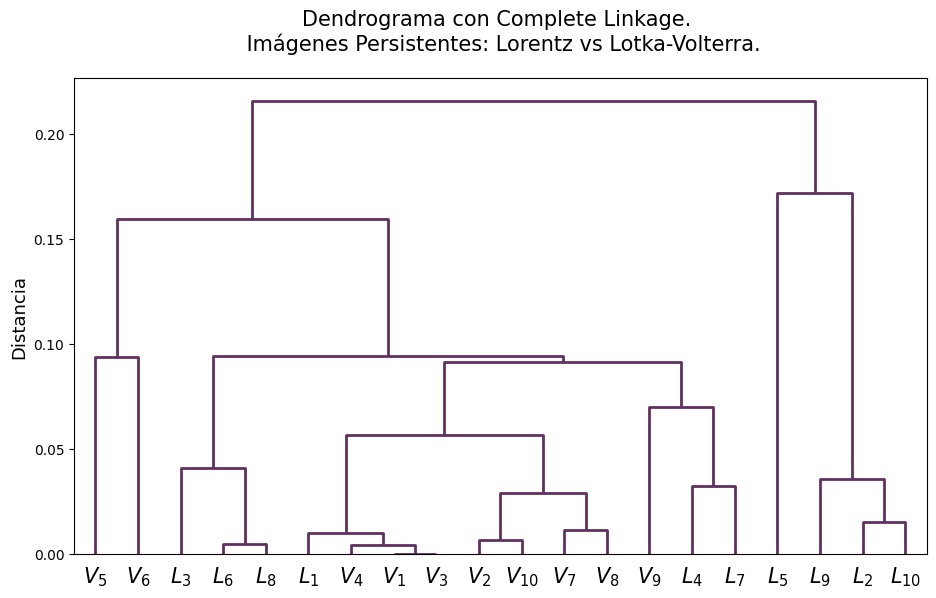

In [94]:
#Calcular el dendrograma complete linkage de la vectorización
Z_C = linkage(imagenes_planas, method='complete', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 0.8
color_final = colores[2]

dendro = dendrogram(Z_C, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.005

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Complete Linkage. \n Imágenes Persistentes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Complete Linkage Imagenes Persistentes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

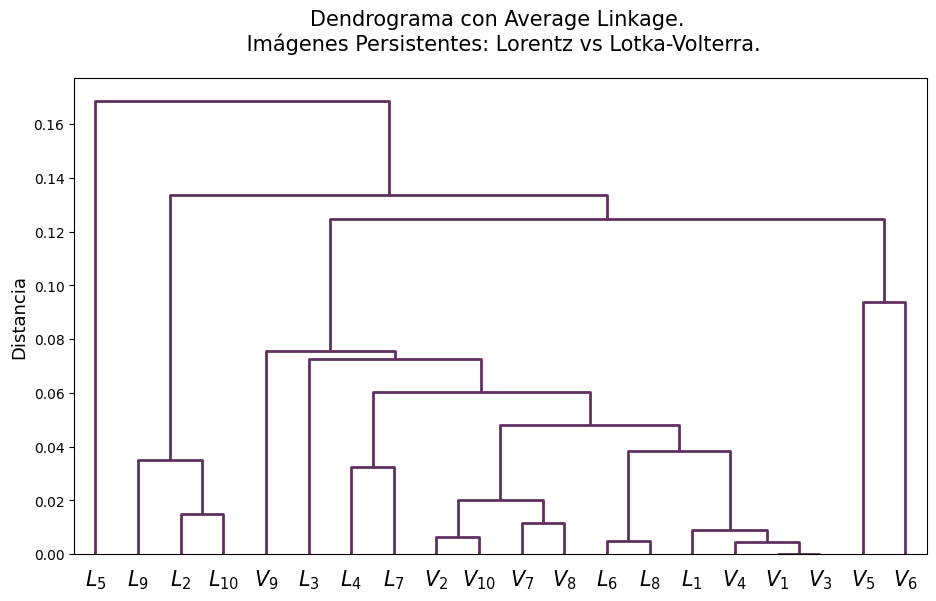

In [95]:
#Calcular el dendrograma average linkage de la vectorización
Z_A = linkage(imagenes_planas, method='average', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 0.6
color_final = colores[2]

dendro = dendrogram(Z_A, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.005

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Average Linkage. \n Imágenes Persistentes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Average Linkage Imagenes Persistentes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()